# Conditional negative-share information and LSEG transfer

**Objective.** Test the dissertation phrase “beyond the mean” directly. The
coefficient of interest is the daily cross-sectional rank coefficient on
negative-story share after mean continuous sentiment and log story count are
in the same regression.

This is a retrospective, non-pooled robustness experiment. FNSPID remains the
primary spine; the two Reuters LSEG time blocks are reported separately.

In [1]:
from __future__ import annotations

import hashlib
import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
if ROOT.name == "final_experiments":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from final_experiments.lib.aggregators import (  # noqa: E402
    AGGREGATOR_NAMES,
    cross_sectional_daily_ic,
)
from final_experiments.lib.conditional_aggregation import (  # noqa: E402
    conditional_negative_share_test,
)
from final_experiments.lib.evaluate import (  # noqa: E402
    TradeConfig,
    build_daily_portfolio,
    summarize_daily_portfolio,
)
from final_experiments.lib.plots import CATEGORICAL, INK, apply_house_style  # noqa: E402

apply_house_style()
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

SEED = 20260812
BOUNDARY = pd.Timestamp("2025-10-27")
OUTPUT = ROOT / "final_experiments/outputs/71_conditional_negative_share_transfer"
SPEC_PATH = ROOT / "final_experiments/frozen_specs/conditional_negative_share_transfer_v1_20260812.json"
OUTPUT.mkdir(parents=True, exist_ok=True)

FNSPID_PATH = ROOT / "final_experiments/outputs/03_aggregation/firm_day_aggregators.parquet"
LSEG_PATHS = {
    ("finbert", "backward"): ROOT / "final_experiments/outputs/67_lseg_gemma_finbert_joined_long_window/backward_finbert_firm_open.parquet",
    ("finbert", "recent"): ROOT / "final_experiments/outputs/67_lseg_gemma_finbert_joined_long_window/recent_finbert_firm_open.parquet",
    ("gemma4_26b", "backward"): ROOT
    / "final_experiments/outputs/67_lseg_gemma_finbert_joined_long_window/backward_gemma4_26b_firm_open.parquet",
    ("gemma4_26b", "recent"): ROOT
    / "final_experiments/outputs/67_lseg_gemma_finbert_joined_long_window/recent_gemma4_26b_firm_open.parquet",
}


def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def bh_qvalues(p_values: list[float] | np.ndarray) -> np.ndarray:
    values = np.asarray(p_values, dtype=float)
    order = np.argsort(values, kind="mergesort")
    ranked = values[order] * len(values) / np.arange(1, len(values) + 1)
    ranked = np.minimum.accumulate(ranked[::-1])[::-1]
    adjusted = np.empty_like(ranked)
    adjusted[order] = np.clip(ranked, 0.0, 1.0)
    return adjusted


print(f"repo:   {ROOT}")
print(f"output: {OUTPUT}")
print(f"spec:   {SPEC_PATH.relative_to(ROOT)}")

repo:   /Users/peterprendergast/Documents/Sentiment_Dissertation
output: /Users/peterprendergast/Documents/Sentiment_Dissertation/final_experiments/outputs/71_conditional_negative_share_transfer
spec:   final_experiments/frozen_specs/conditional_negative_share_transfer_v1_20260812.json


## Frozen design

- Within each session, average-tie percentile-rank the outcome, mean
  continuous sentiment, negative share, and `log(1 + story count)`.
- Regress the outcome rank on all three ranked predictors.
- Average the daily negative-share coefficients with HAC(5) inference.
- FNSPID development is the core direct test.
- Pinned FinBERT is the LSEG primary transfer, with BH correction across the
  backward and recent blocks. Gemma is sensitivity only.
- A null or opposite result narrows the claim; it does not trigger retuning.

In [2]:
spec = json.loads(SPEC_PATH.read_text())
if spec["status"] != "frozen_before_notebook_71_result":
    raise ValueError("unexpected frozen-spec status")

expected_hashes = {
    FNSPID_PATH: spec["inputs"]["fnspid_firm_day_aggregators"]["sha256"],
    LSEG_PATHS[("finbert", "backward")]: spec["inputs"]["lseg_finbert_backward"]["sha256"],
    LSEG_PATHS[("finbert", "recent")]: spec["inputs"]["lseg_finbert_recent"]["sha256"],
    LSEG_PATHS[("gemma4_26b", "backward")]: spec["inputs"]["lseg_gemma_backward"]["sha256"],
    LSEG_PATHS[("gemma4_26b", "recent")]: spec["inputs"]["lseg_gemma_recent"]["sha256"],
}
input_rows = []
for path, expected in expected_hashes.items():
    actual = sha256(path)
    if actual != expected:
        raise ValueError(f"input hash mismatch: {path}")
    input_rows.append(
        {
            "path": str(path.relative_to(ROOT)),
            "sha256": actual,
            "bytes": path.stat().st_size,
        }
    )
input_audit = pd.DataFrame(input_rows)
display(input_audit)

fnspid = pd.read_parquet(FNSPID_PATH)
fnspid["session_date"] = pd.to_datetime(fnspid["session_date"]).dt.normalize()
fnspid_dev = fnspid.loc[fnspid["split"].eq("development")].copy()

lseg: dict[tuple[str, str], pd.DataFrame] = {}
for (scorer, block), path in LSEG_PATHS.items():
    frame = pd.read_parquet(path)
    frame["session_date"] = pd.to_datetime(frame["session_date"]).dt.normalize()
    frame = frame.loc[
        frame["session_date"].lt(BOUNDARY)
        if block == "backward"
        else frame["session_date"].ge(BOUNDARY)
    ].copy()
    frame["n"] = frame["unique_headline_count"].astype(float)
    frame["split"] = block
    lseg[(scorer, block)] = frame

population_audit = pd.DataFrame(
    [
        {
            "source": "FNSPID",
            "scorer": "finbert",
            "block": "development",
            "rows": len(fnspid_dev),
            "sessions": fnspid_dev["session_date"].nunique(),
            "symbols": fnspid_dev["symbol"].nunique(),
            "first_session": fnspid_dev["session_date"].min(),
            "last_session": fnspid_dev["session_date"].max(),
            "median_story_count": float(fnspid_dev["n"].median()),
        },
        *[
            {
                "source": "LSEG",
                "scorer": scorer,
                "block": block,
                "rows": len(frame),
                "sessions": frame["session_date"].nunique(),
                "symbols": frame["symbol"].nunique(),
                "first_session": frame["session_date"].min(),
                "last_session": frame["session_date"].max(),
                "median_story_count": float(frame["n"].median()),
            }
            for (scorer, block), frame in lseg.items()
        ],
    ]
)
display(population_audit)

,path,sha256,bytes
0,final_experiments/outputs/03_aggregation/firm_...,1ca1c38109bc06af232119adeff17de66a567174d45703...,55370575
1,final_experiments/outputs/67_lseg_gemma_finber...,745e6cba49c6dc6e256f9a6495b39eee66679231d162b5...,1331578
2,final_experiments/outputs/67_lseg_gemma_finber...,0931e77d73e723985d0a4b1000a1ee9601f7a4f330d2fa...,516870
3,final_experiments/outputs/67_lseg_gemma_finber...,e2fe9f29791663baad7421abb22bc6b230300cdac2be0a...,1007488
4,final_experiments/outputs/67_lseg_gemma_finber...,5a8534b8de7111a076b1ddb968998e687b51b50bf639b7...,410551


,source,scorer,block,rows,sessions,symbols,first_session,last_session,median_story_count
0,FNSPID,finbert,development,512153,2264,570,2011-01-03,2019-12-31,2.000000
1,LSEG,finbert,backward,14935,456,33,2024-01-02,2025-10-24,61.000000
2,LSEG,finbert,recent,5511,167,33,2025-10-27,2026-06-26,90.000000
3,LSEG,gemma4_26b,backward,14935,456,33,2024-01-02,2025-10-24,61.000000
4,LSEG,gemma4_26b,recent,5511,167,33,2025-10-27,2026-06-26,90.000000


In [3]:
conditional_rows = []
daily_coefficients: dict[str, pd.DataFrame] = {}
exclusion_rows = []

fns_summary, fns_daily, fns_audit = conditional_negative_share_test(
    fnspid_dev,
    date_col="session_date",
    outcome_col="ar_open_h1",
    count_col="n",
    min_names=10,
    hac_lags=5,
)
conditional_rows.append(
    {
        "source": "FNSPID",
        "scorer": "finbert",
        "block": "development",
        "outcome": "ar_open_h1",
        **fns_summary,
    }
)
daily_coefficients["fnspid_finbert_development"] = fns_daily
exclusion_rows.append({"source": "FNSPID", "scorer": "finbert", "block": "development", **fns_audit})

for (scorer, block), frame in lseg.items():
    summary, daily, audit = conditional_negative_share_test(
        frame,
        date_col="session_date",
        outcome_col="raw_open_h1",
        count_col="n",
        min_names=10,
        hac_lags=5,
    )
    conditional_rows.append(
        {
            "source": "LSEG",
            "scorer": scorer,
            "block": block,
            "outcome": "raw_open_h1",
            **summary,
        }
    )
    daily_coefficients[f"lseg_{scorer}_{block}"] = daily
    exclusion_rows.append({"source": "LSEG", "scorer": scorer, "block": block, **audit})

conditional = pd.DataFrame(conditional_rows)
conditional["q_bh_lseg_finbert_two_block"] = np.nan
primary_mask = conditional["source"].eq("LSEG") & conditional["scorer"].eq("finbert")
conditional.loc[primary_mask, "q_bh_lseg_finbert_two_block"] = bh_qvalues(
    conditional.loc[primary_mask, "p_two_sided"].to_numpy(dtype=float)
)
conditional["fnspid_core_pass"] = (
    conditional["source"].eq("FNSPID")
    & conditional["estimate"].lt(0)
    & conditional["p_two_sided"].lt(0.05)
)
conditional["lseg_primary_block_pass"] = (
    primary_mask
    & conditional["estimate"].lt(0)
    & conditional["q_bh_lseg_finbert_two_block"].lt(0.05)
)

exclusion_audit = pd.DataFrame(exclusion_rows)
display(
    conditional[
        [
            "source",
            "scorer",
            "block",
            "estimate",
            "se",
            "t",
            "p_two_sided",
            "q_bh_lseg_finbert_two_block",
            "ci_low",
            "ci_high",
            "n_clusters",
            "direction_matches",
        ]
    ]
)
display(exclusion_audit)

,source,scorer,block,estimate,se,t,p_two_sided,q_bh_lseg_finbert_two_block,ci_low,ci_high,n_clusters,direction_matches
0,FNSPID,finbert,development,-0.008310,0.002954,-2.813066,0.004907,NaN,-0.014100,-0.002520,2264,True
1,LSEG,finbert,backward,-0.028611,0.022559,-1.268291,0.204694,0.409388,-0.072826,0.015603,456,True
2,LSEG,finbert,recent,-0.015727,0.040208,-0.391146,0.695689,0.695689,-0.094534,0.063080,167,True
3,LSEG,gemma4_26b,backward,-0.054429,0.022504,-2.418606,0.015580,NaN,-0.098536,-0.010321,456,True
4,LSEG,gemma4_26b,recent,-0.046630,0.041623,-1.120291,0.262590,NaN,-0.128210,0.034950,167,True


,source,scorer,block,dates_total,dates_used,dates_below_min_names,dates_constant_variable,dates_rank_deficient
0,FNSPID,finbert,development,2264,2264,0,0,0
1,LSEG,finbert,backward,456,456,0,0,0
2,LSEG,finbert,recent,167,167,0,0,0
3,LSEG,gemma4_26b,backward,456,456,0,0,0
4,LSEG,gemma4_26b,recent,167,167,0,0,0


findfont: Failed to find font weight medium, now using 400.


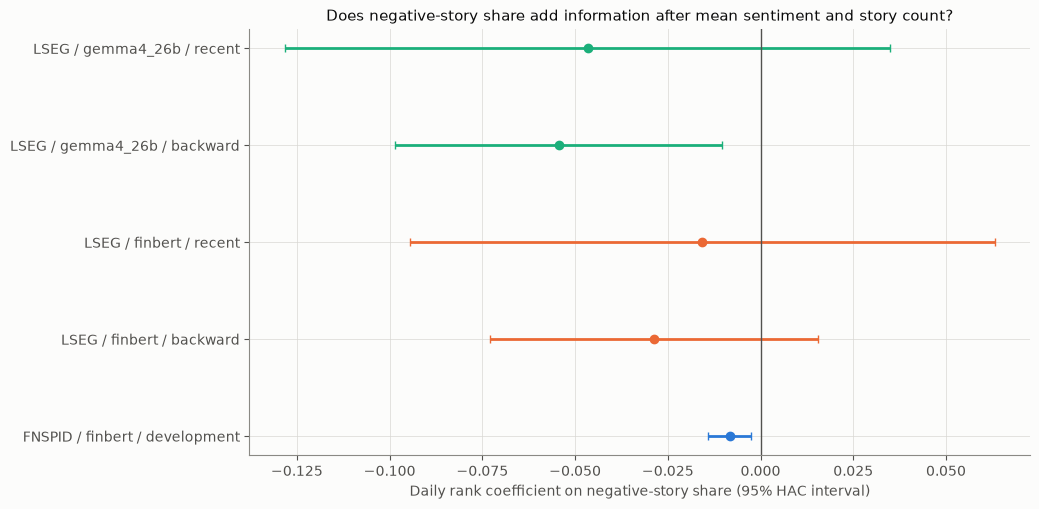

In [4]:
plot_table = conditional.copy()
plot_table["label"] = (
    plot_table["source"] + " / " + plot_table["scorer"] + " / " + plot_table["block"]
)
fig, ax = plt.subplots(figsize=(10.5, 5.2))
y = np.arange(len(plot_table))
colours = [
    CATEGORICAL[0] if source == "FNSPID" else CATEGORICAL[1] if scorer == "finbert" else CATEGORICAL[2]
    for source, scorer in zip(plot_table["source"], plot_table["scorer"], strict=True)
]
for row_number, (_, row) in enumerate(plot_table.iterrows()):
    ax.errorbar(
        row["estimate"],
        row_number,
        xerr=[[row["estimate"] - row["ci_low"]], [row["ci_high"] - row["estimate"]]],
        fmt="o",
        color=colours[row_number],
        capsize=3,
        markersize=6,
    )
ax.axvline(0.0, color=INK["reference"], linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(plot_table["label"])
ax.set_xlabel("Daily rank coefficient on negative-story share (95% HAC interval)")
ax.set_title("Does negative-story share add information after mean sentiment and story count?")
fig.tight_layout()
fig.savefig(OUTPUT / "conditional_negative_share_coefficients.png", dpi=180, bbox_inches="tight")
plt.show()

In [5]:
univariate_rows = []
economic_rows = []
daily_portfolios: dict[str, pd.DataFrame] = {}
trade_config = TradeConfig(
    outcome="raw_open_h1",
    position_mode="cs_rank",
    threshold=0.0,
    min_names=10,
    cost_bps_per_side=10.0,
    bootstrap_block_length=5,
    bootstrap_replications=1_999,
    random_seed=SEED,
)

for (scorer, block), frame in lseg.items():
    for aggregator in AGGREGATOR_NAMES:
        stats = cross_sectional_daily_ic(
            frame[aggregator],
            frame["raw_open_h1"],
            frame["session_date"],
            min_names=10,
            hac_lags=5,
        )
        univariate_rows.append(
            {"source": "LSEG", "scorer": scorer, "block": block, "aggregator": aggregator, **stats}
        )
    daily = build_daily_portfolio(
        frame,
        "negative_share",
        config=trade_config,
        orient=-1.0,
        split=block,
    )
    summary = summarize_daily_portfolio(daily, config=trade_config)
    economic_rows.append(
        {
            "source": "LSEG",
            "scorer": scorer,
            "block": block,
            **summary,
            "total_return_net": float((1.0 + daily["net_return"]).prod() - 1.0),
        }
    )
    daily_portfolios[f"lseg_{scorer}_{block}_negative_share"] = daily

univariate = pd.DataFrame(univariate_rows)
univariate["q_bh_within_scorer_block_nine"] = np.nan
for _, index in univariate.groupby(["scorer", "block"]).groups.items():
    univariate.loc[index, "q_bh_within_scorer_block_nine"] = bh_qvalues(
        univariate.loc[index, "p"].fillna(1.0).to_numpy(dtype=float)
    )
economics = pd.DataFrame(economic_rows)

display(
    univariate.loc[univariate["aggregator"].eq("negative_share")][
        ["scorer", "block", "ic", "se", "t", "p", "q_bh_within_scorer_block_nine", "n_clusters"]
    ]
)
display(
    economics[
        [
            "scorer",
            "block",
            "sharpe_gross",
            "sharpe_net",
            "total_return_net",
            "annualized_turnover",
            "breakeven_bps_per_side",
            "bootstrap_net_ci_low",
            "bootstrap_net_ci_high",
        ]
    ]
)

,scorer,block,ic,se,t,p,q_bh_within_scorer_block_nine,n_clusters
4,finbert,backward,-0.022515,0.010473,-2.149833,0.031568,0.142058,456
13,finbert,recent,0.013970,0.016922,0.825576,0.409044,0.881408,167
22,gemma4_26b,backward,-0.029766,0.010528,-2.827291,0.004694,0.042171,456
31,gemma4_26b,recent,0.009264,0.017325,0.534739,0.592830,0.666934,167


,scorer,block,sharpe_gross,sharpe_net,total_return_net,annualized_turnover,breakeven_bps_per_side,bootstrap_net_ci_low,bootstrap_net_ci_high
0,finbert,backward,1.292561,-2.298727,-0.272877,135.388336,3.603384,-0.001054,-0.000317
1,finbert,recent,-1.608952,-4.722658,-0.225377,125.728161,-5.183865,-0.002216,-0.000765
2,gemma4_26b,backward,1.592853,-1.927531,-0.236203,133.486135,4.531268,-0.000957,-0.000189
3,gemma4_26b,recent,-1.198454,-4.186979,-0.208684,124.499340,-4.034916,-0.002100,-0.000625


In [6]:
fnspid_pass = bool(conditional["fnspid_core_pass"].any())
lseg_primary = conditional.loc[primary_mask]
lseg_portability_pass = bool(
    len(lseg_primary) == 2
    and lseg_primary["estimate"].lt(0).all()
    and lseg_primary["q_bh_lseg_finbert_two_block"].lt(0.05).all()
)

input_audit.to_csv(OUTPUT / "input_audit.csv", index=False)
population_audit.to_csv(OUTPUT / "population_audit.csv", index=False)
conditional.to_csv(OUTPUT / "conditional_coefficients.csv", index=False)
exclusion_audit.to_csv(OUTPUT / "conditional_exclusion_audit.csv", index=False)
univariate.to_csv(OUTPUT / "lseg_univariate_ic_context.csv", index=False)
economics.to_csv(OUTPUT / "lseg_negative_share_economics.csv", index=False)
for name, frame in daily_coefficients.items():
    frame.to_csv(OUTPUT / f"{name}_daily_coefficients.csv", index=False)
for name, frame in daily_portfolios.items():
    frame.to_parquet(OUTPUT / f"{name}_daily.parquet", index=False)

git_commit = subprocess.run(
    ["git", "rev-parse", "HEAD"], cwd=ROOT, check=True, capture_output=True, text=True
).stdout.strip()
manifest = {
    "notebook": "71_conditional_negative_share_transfer",
    "status": "complete_bounded_retrospective_non_pooled_transfer",
    "git_commit_at_execution": git_commit,
    "frozen_spec": str(SPEC_PATH.relative_to(ROOT)),
    "design": spec["estimand"],
    "input_hashes": {str(path.relative_to(ROOT)): digest for path, digest in expected_hashes.items()},
    "results": json.loads(conditional.to_json(orient="records")),
    "fnspid_core_pass": fnspid_pass,
    "lseg_finbert_portability_pass": lseg_portability_pass,
    "economics": json.loads(economics.to_json(orient="records")),
    "claim_boundaries": spec["claim_boundaries"],
}
(OUTPUT / "manifest.json").write_text(json.dumps(manifest, indent=2, allow_nan=True) + "\n")

fns_row = conditional.loc[conditional["source"].eq("FNSPID")].iloc[0]
back_row = lseg_primary.loc[lseg_primary["block"].eq("backward")].iloc[0]
recent_row = lseg_primary.loc[lseg_primary["block"].eq("recent")].iloc[0]
display(
    Markdown(
        f"""### Decision

The direct FNSPID **beyond-the-mean** gate **{'passes' if fnspid_pass else 'does not pass'}**.
Its negative-share coefficient is **{fns_row['estimate']:+.4f}**
(95% HAC interval **[{fns_row['ci_low']:+.4f}, {fns_row['ci_high']:+.4f}]**,
p=**{fns_row['p_two_sided']:.4f}**).

The two-block LSEG FinBERT portability gate **{'passes' if lseg_portability_pass else 'does not pass'}**:

- backward coefficient **{back_row['estimate']:+.4f}**, BH q=**{back_row['q_bh_lseg_finbert_two_block']:.4f}**;
- recent coefficient **{recent_row['estimate']:+.4f}**, BH q=**{recent_row['q_bh_lseg_finbert_two_block']:.4f}**.

This result may strengthen the conditional FNSPID claim or narrow its portability. It cannot
create independent confirmation because all outcome windows were already opened, and it does
not licence a scorer, sign, threshold, horizon, universe, or cost search.
"""
    )
)

### Decision

The direct FNSPID **beyond-the-mean** gate **passes**.
Its negative-share coefficient is **-0.0083**
(95% HAC interval **[-0.0141, -0.0025]**,
p=**0.0049**).

The two-block LSEG FinBERT portability gate **does not pass**:

- backward coefficient **-0.0286**, BH q=**0.4094**;
- recent coefficient **-0.0157**, BH q=**0.6957**.

This result may strengthen the conditional FNSPID claim or narrow its portability. It cannot
create independent confirmation because all outcome windows were already opened, and it does
not licence a scorer, sign, threshold, horizon, universe, or cost search.


## Next step

Carry the exact FNSPID negative-pressure hysteresis rule to the frozen LSEG HAR
base in Notebook 72. Keep the rule, thresholds, costs, and source separation
unchanged regardless of this notebook’s result.